In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [3]:
data = pd.read_csv("../ecommerce_oct/product_price/csv/part-00000-f095e2c9-2f56-4429-bb68-84206dc6f974-c000.csv")
data.head()

,product_id,avg_price
0,6301113,45.723682
1,1004739,192.230384
2,21408554,259.356637
3,17800204,29.559027
4,1004666,1120.127494


Calculating statistics...
--- Price Distribution Statistics ---
count       165647.000000
mean           172.263711
std            291.818227
min              0.770000
25%             23.473182
50%             68.990000
75%            182.752143
max           2574.070000
skew             3.745944
kurtosis        17.842505
Name: avg_price, dtype: float64
----------------------------------------
Generating plot...
Plot successfully saved as 'avg_price_distribution.png'


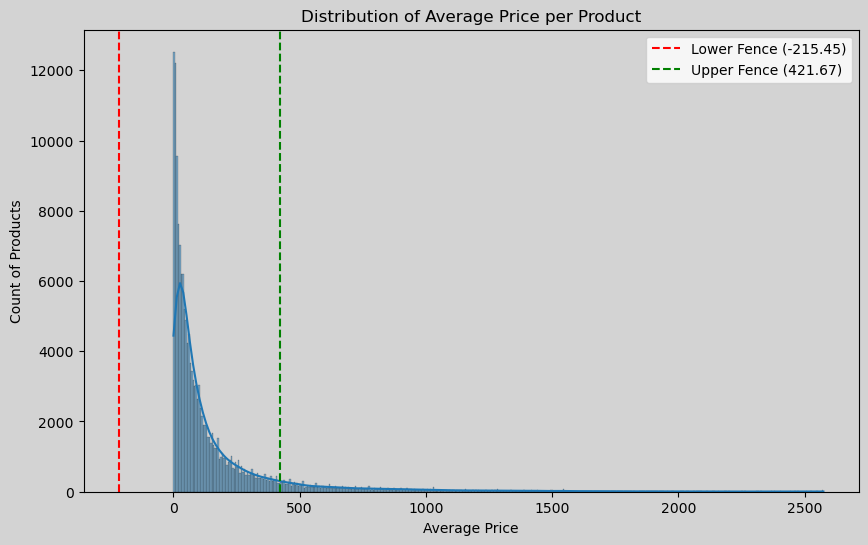

26997

In [4]:
# Select the column for analysis
avg_price_series = data['avg_price']

# --- 2. Calculate Descriptive Statistics ---
print("Calculating statistics...")
price_desc = avg_price_series.describe()
price_desc['skew'] = avg_price_series.skew()
price_desc['kurtosis'] = avg_price_series.kurtosis()

print("--- Price Distribution Statistics ---")
print(price_desc)
print("-" * 40)

# --- 3. Plot the Distribution ---
print("Generating plot...")
plt.figure(figsize=(10, 6), facecolor="lightgray")
ax = plt.gca()
ax.set_facecolor("lightgray")

# Plot histogram and Kernel Density Estimate (KDE)
sns.histplot(x=avg_price_series, kde=True, ax=ax)

# --- 4. Calculate and Add Outlier Fences (1.5 * IQR Rule) ---
q1 = avg_price_series.quantile(0.25)
q3 = avg_price_series.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Add vertical lines for the fences
plt.axvline(lower, color='red', linestyle='--', label=f'Lower Fence ({lower:.2f})')
plt.axvline(upper, color='green', linestyle='--', label=f'Upper Fence ({upper:.2f})')

# --- 5. Finalize and Save Plot ---
plt.legend()
plt.title('Distribution of Average Price per Product')
plt.xlabel('Average Price')
plt.ylabel('Count of Products')

# Save the plot to a file
plot_filename = 'avg_price_distribution.png'
plt.savefig(plot_filename)
print(f"Plot successfully saved as '{plot_filename}'")
plt.show()
# --- 6. Clean Up Memory ---
plt.close()
del ax
del avg_price_series
del price_desc
del data
gc.collect()